# Handwritten Digit Classification with the MNIST Digits Dataset

Build a neural network that recognizes digits (0–9) from images.

Steps

1. Load image data.
2. Understand feature vectors.
3. Scale data.
4. Build an MLP using `MLPClassifier`.
5. Train the model.
6. Evaluate accuracy.
7. Display predictions.
8. Tune hidden layers.

---

# Why the Digits Dataset?

The dataset contains:

* 1,797 images
* Each image is 8×8 pixels
* 64 numerical features
* Labels: digits 0–9

This is much faster than full MNIST while teaching the same core ideas.

---


# Step 1: Load the Dataset

In [1]:

from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data      # shape: (1797, 64)
y = digits.target    # labels 0–9

print(X.shape)
print(y.shape)
print("Classes:", set(y))


(1797, 64)
(1797,)
Classes: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


# Step 2: Visualize a Digit

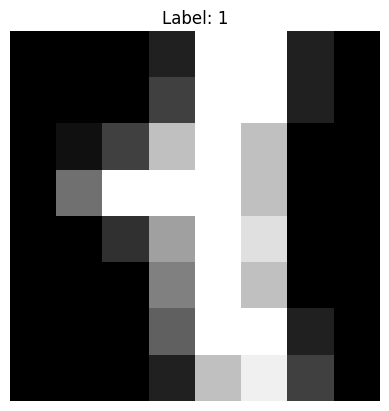

In [4]:
import matplotlib.pyplot as plt

plt.imshow(digits.images[21], cmap='gray')
plt.title(f"Label: {y[21]}")
plt.axis('off')
plt.show()


In [10]:
# Lets look at the first image data and also plot it. We are trybing to understand the image data
# img_idx=0


print(X[21].shape)
print("--------------------")
print(X[21])
print("--------------------")
print(X[21].reshape(8,8))

(64,)
--------------------
[ 0.  0.  0.  2. 16. 16.  2.  0.  0.  0.  0.  4. 16. 16.  2.  0.  0.  1.
  4. 12. 16. 12.  0.  0.  0.  7. 16. 16. 16. 12.  0.  0.  0.  0.  3. 10.
 16. 14.  0.  0.  0.  0.  0.  8. 16. 12.  0.  0.  0.  0.  0.  6. 16. 16.
  2.  0.  0.  0.  0.  2. 12. 15.  4.  0.]
--------------------
[[ 0.  0.  0.  2. 16. 16.  2.  0.]
 [ 0.  0.  0.  4. 16. 16.  2.  0.]
 [ 0.  1.  4. 12. 16. 12.  0.  0.]
 [ 0.  7. 16. 16. 16. 12.  0.  0.]
 [ 0.  0.  3. 10. 16. 14.  0.  0.]
 [ 0.  0.  0.  8. 16. 12.  0.  0.]
 [ 0.  0.  0.  6. 16. 16.  2.  0.]
 [ 0.  0.  0.  2. 12. 15.  4.  0.]]


```
* Each image is 8×8.
* Pixel values become 64 input features.
* The network predicts one of 10 classes.


# Step 3: Train-Test Split and Scaling


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Step 4: Build the MLP Model


In [13]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)


```

Architecture:

* Input layer: 64 neurons
* Hidden layer 1: 64 neurons
* Hidden layer 2: 32 neurons
* Output layer: 10 neurons



# Step 5: Train the Model

In [14]:


model.fit(X_train_scaled, y_train)


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)

# Step 6: Make Predictions

In [15]:

y_pred = model.predict(X_test_scaled)


In [17]:
# compare actual vs predicted
print("actual :", y_test)
print("predict:", y_pred)

actual : [6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8 4 3 9 7 5 6 3 5 6 3 4 9 1 4 4 6 9
 4 7 6 6 9 1 3 6 1 3 0 6 5 5 1 9 5 6 0 9 0 0 1 0 4 5 2 4 5 7 0 7 5 9 5 5 4
 7 0 4 5 5 9 9 0 2 3 8 0 6 4 4 9 1 2 8 3 5 2 9 0 4 4 4 3 5 3 1 3 5 9 4 2 7
 7 4 4 1 9 2 7 8 7 2 6 9 4 0 7 2 7 5 8 7 5 7 7 0 6 6 4 2 8 0 9 4 6 9 9 6 9
 0 3 5 6 6 0 6 4 3 9 3 9 7 2 9 0 4 5 3 6 5 9 9 8 4 2 1 3 7 7 2 2 3 9 8 0 3
 2 2 5 6 9 9 4 1 5 4 2 3 6 4 8 5 9 5 7 8 9 4 8 1 5 4 4 9 6 1 8 6 0 4 5 2 7
 4 6 4 5 6 0 3 2 3 6 7 1 5 1 4 7 6 8 8 5 5 1 6 2 8 8 9 9 7 6 2 2 2 3 4 8 8
 3 6 0 9 7 7 0 1 0 4 5 1 5 3 6 0 4 1 0 0 3 6 5 9 7 3 5 5 9 9 8 5 3 3 2 0 5
 8 3 4 0 2 4 6 4 3 4 5 0 5 2 1 3 1 4 1 1 7 0 1 5 2 1 2 8 7 0 6 4 8 8 5 1 8
 4 5 8 7 9 8 5 0 6 2 0 7 9 8 9 5 2 7 7 1 8 7 4 3 8 3 5]
predict: [6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8 4 3 9 7 5 6 3 5 6 3 4 9 1 4 4 6 9
 4 7 6 6 9 1 3 6 1 3 0 6 5 5 1 3 5 6 0 9 0 0 1 0 4 5 2 4 5 7 0 7 5 9 5 5 4
 7 0 4 5 5 9 9 0 2 3 8 0 6 4 4 9 1 2 8 3 5 2 9 0 4 4 4 3 5 3 1 3 5 9 4 2 7
 7 4 4 1 9 2 7 8 7 2 6 9 4

# Step 7: Evaluate the Model


In [18]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9805555555555555
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  1  0 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  0  0  0  0  0  0  0 30  0]
 [ 0  0  0  1  0  0  0  0  1 38]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      1.00      0.98        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98 


# Step 8: Visualize Predictions


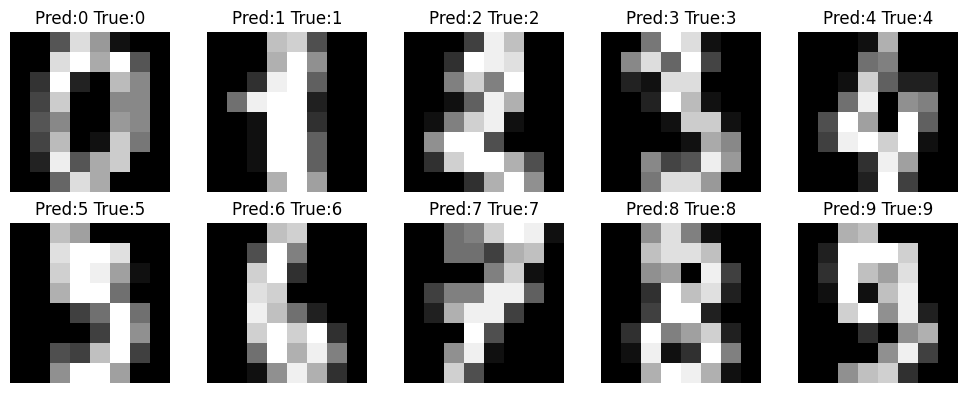

In [20]:

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, pred, true in zip(
    axes.ravel(),
    digits.images[:10],
    model.predict(scaler.transform(X[:10])),
    y[:10]
):
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Pred:{pred} True:{true}")
    ax.axis('off')

plt.tight_layout()
plt.show()


# Step 9: Show the Loss Curve


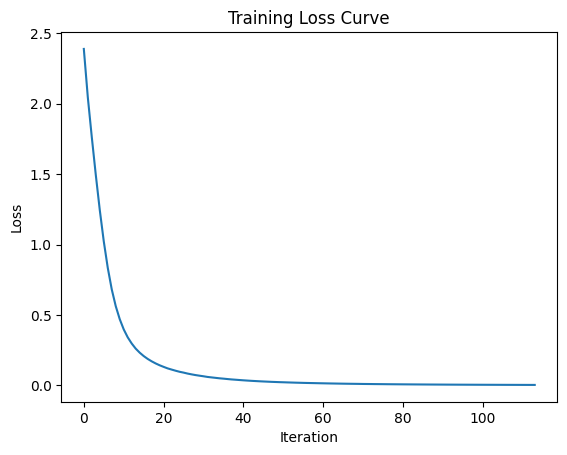

In [21]:

plt.plot(model.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()


This is  gradient descent in action.


# Step 10: Experiment with Network Architecture

In [26]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

for layers in [(8,), (16,), (32,), (64,), (64, 32), (128, 64)]:
    model = MLPClassifier(
        hidden_layer_sizes=layers,
        max_iter=100,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    print(layers, "Accuracy:", round(acc, 4))


(8,) Accuracy: 0.9139
(16,) Accuracy: 0.9667
(32,) Accuracy: 0.975
(64,) Accuracy: 0.9833
(64, 32) Accuracy: 0.9778
(128, 64) Accuracy: 0.9722


## MLP Architecture

```text
64 inputs (pixels)
        ↓
Hidden Layer 1: 64 neurons
        ↓
Hidden Layer 2: 32 neurons
        ↓
10 outputs (digits 0–9)
```

---

# Key Hyperparameters

* `hidden_layer_sizes`
* `activation`
* `solver`
* `learning_rate_init`
* `max_iter`

---
